<p class="mlx-kicker">Part IV &middot; Beyond the block &middot; Chapter 12</p>

# 12. Scale: from scaling laws to emergence

<dl class="mlx-meta"><div><dt>Level</dt><dd>Intermediate</dd></div><div><dt>Reading</dt><dd>about 25 min</dd></div><div><dt>Hands-on</dt><dd>about 5 min on a laptop CPU</dd></div><div><dt>You should know</dt><dd>Chapter 1 (the model), chapter 10 (learning-rate schedules), logarithms</dd></div></dl>

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daiyip/ml-explained/blob/main/chapters/12-scale/index.ipynb)

![Three generations of thinking about scale. Each column highlights what is new: loss falls as a straight line on log-log axes in parameters, data and compute; for a fixed compute budget, parameters and training tokens should grow together; and a large enough model learns new tasks from examples in its prompt, with abilities that look sudden or smooth depending on how they are measured.](figures/scale-lineage.svg)

## What changed, and why it works

The previous chapters changed one block of the Transformer at a time. This chapter keeps the block fixed and asks what happens when you make everything bigger: more parameters, more training tokens, more compute. The surprising answer, found around 2017 to 2020, is that test loss improves in a smooth and predictable way, as a power law, over many orders of magnitude. That predictability turned building language models into an engineering plan. The guiding question is *why is loss a smooth power law in compute?* Each generation in Figure 12.1 adds one idea.

<div class="mlx-why">
<section class="mlx-why__card mlx-why__card--1"><p class="mlx-why__n">1 &middot; Scaling laws</p><h3>Loss is a power law in N, D and C</h3><p><b>What changed.</b> Instead of asking whether a bigger model helps, Kaplan et al. (2020) measured how much: test loss falls as a power of the parameter count N, the dataset size D and the compute C, a straight line on log-log axes across seven orders of magnitude.</p><p><b>Why it works.</b> The loss averages over a huge number of patterns of very different frequency, from common letter pairs to rare facts. Each increase in capacity or data lets the model resolve a further slice of rarer patterns, and when pattern frequencies follow a heavy-tailed (Zipf-like) distribution, the sum of what is still unresolved shrinks as a power law. No single pattern is smooth, but their sum is. <b>[likely]</b></p><p class="mlx-why__run">Our run: 7 models from 3k to 148k parameters fit L(N) = 3.9 / N<sup>0.057</sup>; fitted on the 4 smallest, it forecasts the 3 largest within 0.03 nats</p></section>
<section class="mlx-why__card mlx-why__card--2"><p class="mlx-why__n">2 &middot; Chinchilla</p><h3>Grow parameters and tokens together</h3><p><b>What changed.</b> Hoffmann et al. (2022) trained over 400 models at fixed compute budgets and found that the best model size grows only as the square root of compute, with training tokens growing at the same rate: about 20 tokens per parameter. Their 70B-parameter Chinchilla beat the 280B Gopher at the same compute.</p><p><b>Why it works.</b> With compute C &asymp; 6ND fixed, a bigger model must see fewer tokens. Loss has one error term that shrinks with N and one that shrinks with D. Too small a model leaves the first term large; too big a model is undertrained and leaves the second large. The minimum sits where the two terms trade off evenly, and since they shrink at similar rates, N and D grow at similar rates.</p><p class="mlx-why__run">Our runs: the best size grows from about 3,900 to 26,000 parameters over 8&times; more compute; with only 1M characters of data, tokens barely grow (N &prop; C<sup>0.92</sup>)</p></section>
<section class="mlx-why__card mlx-why__card--3"><p class="mlx-why__n">3 &middot; In-context learning</p><h3>Learn from the prompt, and watch the metric</h3><p><b>What changed.</b> GPT-3 (Brown et al., 2020) showed that a big enough model can do a new task from a few examples in its prompt, with no weight update. Wei et al. (2022) catalogued abilities that seemed to switch on suddenly with scale; Schaeffer et al. (2023) argued many such jumps come from the metric, not the model.</p><p><b>Why it works.</b> When every training sequence is generated by a different underlying rule, the only way to predict its next token well is to infer the rule from the earlier tokens, so the network learns a learning algorithm that runs in its forward pass. Sudden jumps appear when the score needs k tokens all correct: a per-token accuracy p that rises smoothly gives an exact-match score near p<sup>k</sup>, which stays near zero and then shoots up.</p><p class="mlx-why__run">Our runs: a 3-layer model cuts its error on unseen functions from 1.09 to 0.09 with 8 prompt examples; per-character accuracy rises smoothly from 0.30 to 0.43 while 10-character exact match stays near zero</p></section>
</div>

Read left to right, the question moves from *how does loss scale*, to *how should a fixed budget be spent*, to *what does lower loss buy in practice*. The steps below reproduce each idea with models small enough to train on a laptop.

## Evolution path

| Year | Step | Level | What changed |
| --- | --- | --- | --- |
| 2017 | Deep learning scaling is predictable (Hestness et al.) | minor | power-law learning curves measured in translation, speech, vision and language |
| 2020 | Scaling laws for neural language models (Kaplan et al.) | **major** | loss as a power law in N, D and C; advice: spend most extra compute on parameters |
| 2020 | GPT-3 and in-context learning | **major** | a 175B model does new tasks from a few prompt examples |
| 2022 | Chinchilla compute-optimal training (Hoffmann et al.) | **major** | N and D grow together, about 20 tokens per parameter |
| 2022 | Emergent abilities (Wei et al.) | minor | task scores that jump from chance to well above it between model sizes |
| 2023 | The "mirage" critique (Schaeffer et al.) | minor | many jumps vanish under continuous metrics such as per-token loss |
| 2023-2024 | Training past Chinchilla (LLaMA and successors) | minor | small models trained on far more tokens, because inference cost matters too |

## The lineage post-mortem: what drove each replacement?

| Replacement | Pressure that drove it | What it bought |
| --- | --- | --- |
| trial and error to scaling laws | each bigger model was an expensive gamble | predict a large model's loss from a few small runs |
| Kaplan allocation to Chinchilla | Kaplan's fits said "mostly parameters"; tuned runs disagreed | about 4&times; smaller models for the same loss, cheaper to serve |
| task-specific fine-tuning to in-context learning | a new labelled dataset and a new model for every task | one model, many tasks, specified by examples in the prompt |
| "emergence" to the mirage critique | abilities looked unpredictable, which would make scaling unplannable | a reminder to choose metrics that track the underlying loss |

The first two rows are about *planning*: a power law is a forecast, and it decides how many GPUs to buy and for how long. The last two are about *what the loss means*: the loss is smooth, but the abilities people care about are measured by thresholded scores, and those can still surprise. The field's present answer to the guiding question is that the smoothness is a property of the average over many skills, not of any one skill.

**Still open:** why the exponents take the values they do, and whether they are set by the data (its intrinsic dimension or the distribution of its patterns) or by the architecture; how far the power laws continue before the data runs out; how to forecast specific abilities, not just loss; and how scaling applies to compute spent at inference time, such as long chains of reasoning.

## Run it yourself

The steps share this setup. Steps 1 and 2 train a ladder of small character-level Transformers on TinyShakespeare, the same model as chapter 1 at widths from 16 to 64. Step 3 trains a small Transformer on synthetic regression problems. Step 4 reuses the models from step 1. Everything runs on one CPU thread in about 5 minutes.

In [1]:
# Setup: works from a checkout of the repo and on Google Colab.
import pathlib, subprocess, sys

try:
    import mlexp
except ImportError:
    root = pathlib.Path.cwd().resolve().parents[1]
    if (root / "mlexp").is_dir():
        sys.path.insert(0, str(root))
    else:  # Colab: install the shared helpers from GitHub
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/daiyip/ml-explained"], check=True)
    import mlexp

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0)
mlexp.setup_style()
device_note = "GPU available" if torch.cuda.is_available() else "running on CPU"
print(f"torch {torch.__version__}, {device_note}")

torch 2.14.1+cu130, running on CPU


In [2]:
import time
from mlexp.transformer import Block, RMSNorm, TransformerLM

torch.set_num_threads(1)  # we ran the notebook on one thread; raise this on your own machine
tok, train_ids, val_ids = mlexp.load_char_corpus()
notebook_start = time.time()

### Step 1 (major): scaling laws

#### The problem before

Until about 2019, whether a bigger network would help was settled run by run. A lab trained a model, tried a larger one, and hoped. Hestness et al. (2017) noticed that learning curves in several domains followed power laws, but it was Kaplan et al. (2020) who measured it carefully for Transformer language models and turned it into a tool.

#### The idea

Train a family of models that differ only in size, and plot their test loss against the number of parameters N on log-log axes. Kaplan et al. found a straight line, which means a power law. The same held for dataset size D (when the model is large enough) and for compute C (when model size is chosen well for each budget). Their fitted exponents were small: loss falls by about 5% for every doubling of N (exponent 0.076) and about 3.5% per doubling of compute (exponent 0.050). **[established]**

A pure power law would go to zero loss, which is impossible: text has some irreducible randomness. Later work therefore adds a floor `\(E\)`, the entropy of the text that no model can remove. The second number to know is the compute of a training run: each parameter costs about 2 floating-point operations per token on the forward pass and 4 on the backward pass.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equations: a scaling law and the cost of training</p><div class="mlx-eq">$$L(N) = E + \frac{A}{N^{\alpha}}, \qquad C \approx 6\,N\,D$$</div><p class="mlx-eq__where">\(L\) is the test loss in nats per token, \(N\) the parameter count, \(D\) the number of training tokens and \(C\) the training FLOPs. \(E\) is the irreducible loss; \(A\) and \(\alpha\) are fitted. Taking logs, \(\log(L - E) = \log A - \alpha \log N\): a straight line with slope \(-\alpha\).</p></div>

Following Kaplan et al., we count only the parameters inside the Transformer blocks ("non-embedding" parameters). Our models use characters, so the embedding table is tiny anyway.

#### Minimal implementation

The helpers below build a model of a given width and depth, train it with the shared loop for a fixed number of steps, and measure its loss on a fixed 64,000-character slice of the validation text.

In [3]:
TOKENS_PER_STEP = 16 * 64  # each step sees 16 windows of 64 characters
LADDER = [(16, 1), (16, 2), (24, 2), (32, 2), (40, 3), (48, 3), (64, 3)]  # (width, layers)

VAL_X = val_ids[:65536].view(-1, 64)  # 1,024 fixed validation windows
VAL_Y = val_ids[1:65537].view(-1, 64)


def make_model(dim, n_layers):
    torch.manual_seed(0)
    return TransformerLM(tok.vocab_size, dim=dim, n_layers=n_layers, n_heads=max(1, dim // 16))


def block_params(model):
    """Non-embedding parameters: everything except the token embedding and the output head."""
    return mlexp.count_params(model) - mlexp.count_params(model.embed) - mlexp.count_params(model.head)


@torch.no_grad()
def val_loss(model):
    model.eval()
    losses = [model(VAL_X[i:i + 128], VAL_Y[i:i + 128], include_aux=False)[1].item() for i in range(0, len(VAL_X), 128)]
    model.train()
    return sum(losses) / len(losses)


def train_for(model, steps):
    mlexp.train_lm(model, train_ids, val_ids, steps=steps, batch_size=16, block_size=64,
                   eval_every=steps, eval_iters=2, log=False)
    return val_loss(model)


for dim, n_layers in LADDER:
    print(f"width {dim:3d}, {n_layers} layers: {block_params(make_model(dim, n_layers)):7,d} block parameters")

width  16, 1 layers:   3,088 block parameters
width  16, 2 layers:   6,160 block parameters
width  24, 2 layers:  13,944 block parameters
width  32, 2 layers:  24,672 block parameters
width  40, 3 layers:  57,640 block parameters
width  48, 3 layers:  83,280 block parameters
width  64, 3 layers: 147,520 block parameters


#### Experiment: a ladder of model sizes

We train the seven models for the same 500 steps, so every model sees the same 512,000 characters. Then we fit `\(L(N) = E + A / N^{\alpha}\)`. With only three parameters to fit, the simplest method is to try many values of the floor `\(E\)` and, for each, fit a straight line to `\(\log(L - E)\)` against `\(\log N\)`, keeping the best. Finally we do what labs use scaling laws for: fit only the four smallest models and forecast the loss of the three largest before looking at them.

N =   3,088   val loss 2.450


N =   6,160   val loss 2.353


N =  13,944   val loss 2.267


N =  24,672   val loss 2.189


N =  57,640   val loss 2.062


N =  83,280   val loss 2.036


N = 147,520   val loss 1.971
ladder trained in 72s
fit: L(N) = 0.00 + 3.9 / N^0.057     (pure power law without a floor: exponent 0.057)
forecast for N =  57,640: 2.096   measured 2.062
forecast for N =  83,280: 2.055   measured 2.036
forecast for N = 147,520: 1.994   measured 1.971


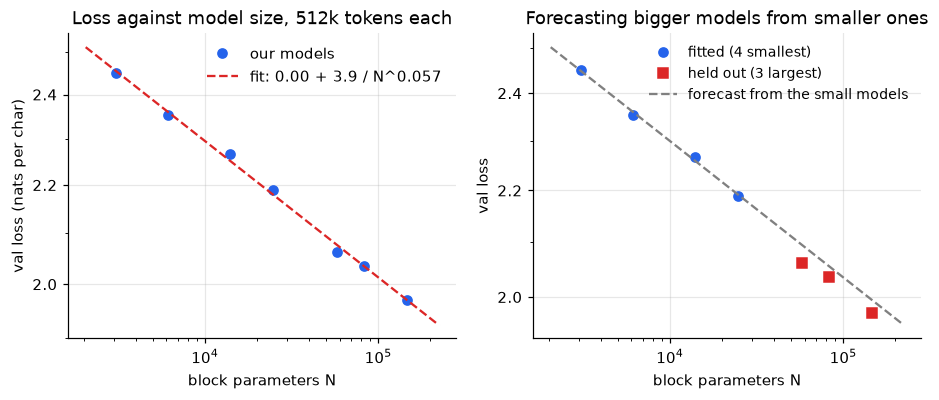

In [4]:
ladder = []  # one entry per model size; step 4 reuses the trained models
t0 = time.time()
for dim, n_layers in LADDER:
    model = make_model(dim, n_layers)
    loss = train_for(model, steps=500)
    ladder.append({"N": block_params(model), "loss": loss, "model": model})
    print(f"N = {ladder[-1]['N']:7,d}   val loss {loss:.3f}")
print(f"ladder trained in {time.time() - t0:.0f}s")


def fit_power_law(x, y):
    """Fit y = E + A * x**(-alpha): scan the floor E, fit a line in log-log space for each, keep the best."""
    x, y, best = np.asarray(x, float), np.asarray(y, float), None
    for E in np.linspace(0, y.min() - 1e-3, 500):
        slope, intercept = np.polyfit(np.log(x), np.log(y - E), 1)
        err = np.sum((E + np.exp(intercept) * x ** slope - y) ** 2)
        if best is None or err < best[0]:
            best = (err, E, np.exp(intercept), -slope)
    return best[1:]


Ns = np.array([r["N"] for r in ladder])
Ls = np.array([r["loss"] for r in ladder])
E, A, alpha = fit_power_law(Ns, Ls)
pure_slope = -np.polyfit(np.log(Ns), np.log(Ls), 1)[0]
print(f"fit: L(N) = {E:.2f} + {A:.1f} / N^{alpha:.3f}     (pure power law without a floor: exponent {pure_slope:.3f})")

# The real use of a scaling law: fit the four smallest models, forecast the three largest.
slope, icpt = np.polyfit(np.log(Ns[:4]), np.log(Ls[:4]), 1)
forecast = np.exp(icpt) * Ns[4:] ** slope
for n, f, l in zip(Ns[4:], forecast, Ls[4:]):
    print(f"forecast for N = {n:7,d}: {f:.3f}   measured {l:.3f}")

grid = np.geomspace(Ns.min() / 1.5, Ns.max() * 1.5, 100)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))
ax1.loglog(Ns, Ls, "o", label="our models")
ax1.loglog(grid, E + A * grid ** -alpha, "--", label=f"fit: {E:.2f} + {A:.1f} / N^{alpha:.3f}")
ax1.set(xlabel="block parameters N", ylabel="val loss (nats per char)", title="Loss against model size, 512k tokens each")
ax1.legend(frameon=False)
ax2.loglog(Ns[:4], Ls[:4], "o", label="fitted (4 smallest)")
ax2.loglog(Ns[4:], Ls[4:], "s", label="held out (3 largest)")
ax2.loglog(grid, np.exp(icpt) * grid ** slope, "--", color="gray", label="forecast from the small models")
ax2.set(xlabel="block parameters N", ylabel="val loss", title="Forecasting bigger models from smaller ones")
ax2.legend(frameon=False, fontsize=9)
for ax in (ax1, ax2):  # plain tick labels on the log loss axis
    ax.set_yticks([2.0, 2.2, 2.4], ["2.0", "2.2", "2.4"])
    ax.yaxis.set_minor_formatter(plt.NullFormatter())

#### Why it worked: a post-mortem

**The points fall on a power law.** Loss drops from 2.450 to 1.971 as the model grows 48&times;, from 3,088 to 147,520 parameters, and the seven points lie close to a straight line on log-log axes with slope -0.057. This is the shape Kaplan et al. found over seven orders of magnitude; ours covers less than two. **[established]** for the shape; our exponent is one measurement on one dataset.

**The floor is not visible yet.** The best-fitting floor is `\(E = 0\)`: over less than two decades of N, a curve that bends toward a floor and a pure power law look the same, so the data cannot pin `\(E\)` down. The entropy of English text is certainly above zero (Shannon estimated around 1 bit, about 0.7 nats, per character). Chinchilla could estimate its floor of 1.69 nats per token only because its fits spanned models from 70M to 16B parameters. Fitting the floor is the least reliable part of any scaling law. **[established]**

**The forecast works.** Fitted on the four smallest models only, the power law predicts 2.096, 2.055 and 1.994 for the three largest; they measured 2.062, 2.036 and 1.971. The forecast is off by 0.02 to 0.03 nats, and on the pessimistic side, so the larger models did slightly better than the trend of the small ones. This is how GPT-4's final loss was predicted from runs using at most 1/10,000 of its compute (OpenAI, 2023). **[established]** that such forecasts work at scale; ours is a small check.

**Our exponent is not Kaplan's, and it should not be.** Kaplan's 0.076 was measured on word-piece tokens with models trained close to convergence; ours are character models that all saw the same 512,000 characters, so the larger ones are increasingly undertrained. Exponents depend on the data, the tokenizer and how training is run. **[established]**

**Why a power law at all?** No one has a proof, but two explanations are widely discussed. One says a model fits the data manifold piece by piece, so the error falls with the resolution it can afford, giving an exponent set by the intrinsic dimension of the data (Sharma and Kaplan, 2020). **[speculative]** The other, the "quantization" view (Michaud et al., 2023), says language is a mix of many separate skills whose usefulness follows a Zipf-like distribution; a bigger model learns the next most frequent skills, and summing the leftover skills gives a power law. **[speculative]** Both agree on the key point: the smooth curve is an average over many small, uneven improvements. **[likely]**

### Step 2 (major): compute-optimal allocation (Chinchilla)

#### The problem before

Given a fixed compute budget, how big should the model be? Kaplan et al. (2020) concluded that model size should grow fast with compute, as `\(N \propto C^{0.73}\)`, with the number of training tokens growing only as `\(C^{0.27}\)`. The models that followed, GPT-3 (175B parameters, 300B tokens) and Gopher (280B parameters, 300B tokens), were very large and trained on comparatively few tokens.

#### The idea

Hoffmann et al. (2022) re-did the measurement with a cleaner design. In one of their three methods, the **IsoFLOP** analysis, they fix a compute budget, train models of several sizes with exactly that budget (a smaller model sees more tokens), and find the size with the lowest loss. Repeating this at several budgets traces how the best size grows. Their answer: `\(N_{\text{opt}} \propto C^{0.50}\)` and `\(D_{\text{opt}} \propto C^{0.50}\)`, roughly 20 tokens per parameter. Chinchilla, 70B parameters on 1.4T tokens, used the same compute as Gopher and beat it on almost every benchmark. **[established]**

Why did the two papers disagree? Hoffmann et al. pointed to Kaplan's learning-rate schedule: Kaplan used one cosine schedule length for runs of different lengths, so runs stopped early were judged before their learning rate had decayed, which made small models trained on many tokens look worse. Later re-analyses (Pearce and Song, 2024; Porian et al., 2024) add that counting only non-embedding parameters, and the small scale of Kaplan's models, also bias the exponent upward. **[likely]** In our runs every model gets a full cosine schedule for its own length, as in Chinchilla.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equation: why N and D grow together</p><div class="mlx-eq">$$L(N, D) = E + \frac{A}{N^{\alpha}} + \frac{B}{D^{\beta}} \quad\text{with}\quad C = 6ND \quad\Longrightarrow\quad N_{\text{opt}} \propto C^{\frac{\beta}{\alpha+\beta}}, \quad D_{\text{opt}} \propto C^{\frac{\alpha}{\alpha+\beta}}$$</div><p class="mlx-eq__where">Substitute \(D = C / 6N\) and set the derivative with respect to \(N\) to zero. Chinchilla's fit gave \(\alpha \approx 0.34\) and \(\beta \approx 0.28\), so both exponents are close to \(\tfrac12\).</p></div>

#### Experiment: three IsoFLOP curves

For each of three budgets we pick four or five sizes from the ladder and set each model's number of steps so that `\(6ND\)` equals the budget. The smallest budget trains the 3k-parameter model for about 1,300 steps but the 25k model for under 200.

<div class="mlx-box mlx-box--predict"><p class="mlx-box__label">Predict first</p><p class="mlx-predict__q">At the largest budget, 2&times;10<sup>11</sup> FLOPs, the 14k-parameter model can see about 2.4 million characters and the 148k model only about 230,000. Which size gives the lowest loss: the smallest, the largest, or one in between? And how many tokens per parameter will the winner have seen, compared with Chinchilla's 20?</p><details><summary>Show what happened</summary><p>One in between. The 25k model wins (2.010), just ahead of the 14k (2.022) and 58k (2.033) models; the 148k model is last (2.198), starved of data. The fitted optimum, about 26,000 parameters, saw about 49 characters per parameter, more than Chinchilla's 20. Step 2's post-mortem explains why the ratio is not constant here.</p></details></div>

In [5]:
BUDGETS = {  # compute budget in FLOPs -> ladder sizes to try (width, layers)
    2.5e10: [(16, 1), (16, 2), (24, 2), (32, 2)],
    7e10: [(16, 2), (24, 2), (32, 2), (40, 3)],
    2e11: [(24, 2), (32, 2), (40, 3), (48, 3), (64, 3)],
}
iso = {C: [] for C in BUDGETS}
t0 = time.time()
for C, sizes in BUDGETS.items():
    for dim, n_layers in sizes:
        model = make_model(dim, n_layers)
        N = block_params(model)
        steps = round(C / (6 * N * TOKENS_PER_STEP))  # spend exactly the budget: D = C / 6N
        iso[C].append({"N": N, "D": steps * TOKENS_PER_STEP, "loss": train_for(model, steps)})
        r = iso[C][-1]
        print(f"C = {C:.1e}  N = {N:7,d}  steps {steps:5d}  D = {r['D']:9,d}  ({r['D'] / N:5.0f} tokens/param)  val loss {r['loss']:.3f}")
print(f"IsoFLOP sweep trained in {time.time() - t0:.0f}s")

C = 2.5e+10  N =   3,088  steps  1318  D = 1,349,632  (  437 tokens/param)  val loss 2.316


C = 2.5e+10  N =   6,160  steps   661  D =   676,864  (  110 tokens/param)  val loss 2.307


C = 2.5e+10  N =  13,944  steps   292  D =   299,008  (   21 tokens/param)  val loss 2.386


C = 2.5e+10  N =  24,672  steps   165  D =   168,960  (    7 tokens/param)  val loss 2.438


C = 7.0e+10  N =   6,160  steps  1850  D = 1,894,400  (  308 tokens/param)  val loss 2.163


...

C = 2.0e+11  N =  13,944  steps  2334  D = 2,390,016  (  171 tokens/param)  val loss 2.022


C = 2.0e+11  N =  24,672  steps  1319  D = 1,350,656  (   55 tokens/param)  val loss 2.010


C = 2.0e+11  N =  57,640  steps   565  D =   578,560  (   10 tokens/param)  val loss 2.033


C = 2.0e+11  N =  83,280  steps   391  D =   400,384  (    5 tokens/param)  val loss 2.091


C = 2.0e+11  N = 147,520  steps   221  D =   226,304  (    2 tokens/param)  val loss 2.198
IsoFLOP sweep trained in 156s


C = 2.5e+10: best N about   3,870, trained on D about 1,076,544 tokens (278 tokens per parameter)
C = 7.0e+10: best N about   8,521, trained on D about 1,369,119 tokens (161 tokens per parameter)
C = 2.0e+11: best N about  25,980, trained on D about 1,283,024 tokens (49 tokens per parameter)
N_opt ~ C^0.92, D_opt ~ C^0.08  (Chinchilla: 0.50 and 0.50; Kaplan: 0.73 and 0.27)


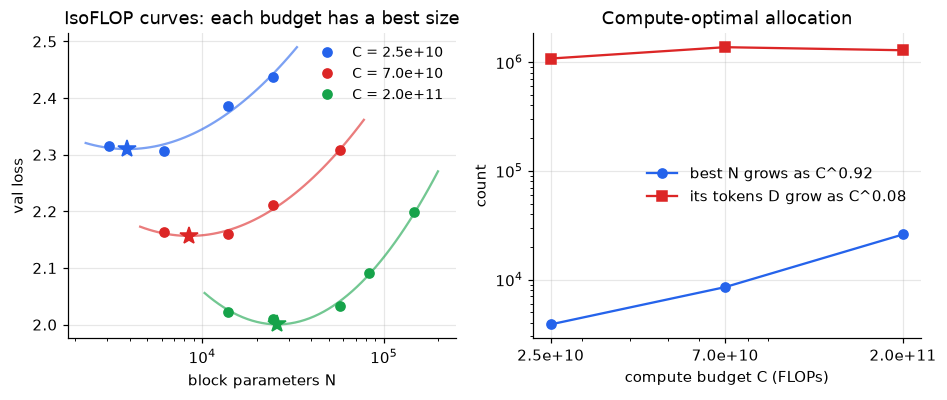

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))
best = []
for C, runs in iso.items():
    logN = np.log([r["N"] for r in runs])
    L = np.array([r["loss"] for r in runs])
    a, b, c = np.polyfit(logN, L, 2)  # a parabola in log N, as in Chinchilla
    n_opt = np.exp(-b / (2 * a))
    best.append((C, n_opt, C / (6 * n_opt)))
    line, = ax1.semilogx(np.exp(logN), L, "o", label=f"C = {C:.1e}")
    xs = np.linspace(logN.min() - 0.3, logN.max() + 0.3, 50)
    ax1.semilogx(np.exp(xs), np.polyval([a, b, c], xs), "-", color=line.get_color(), alpha=0.6)
    ax1.plot(n_opt, np.polyval([a, b, c], np.log(n_opt)), "*", ms=12, color=line.get_color())
    print(f"C = {C:.1e}: best N about {n_opt:7,.0f}, trained on D about {C / (6 * n_opt):9,.0f} tokens"
          f" ({C / (6 * n_opt) / n_opt:.0f} tokens per parameter)")
ax1.set(xlabel="block parameters N", ylabel="val loss", title="IsoFLOP curves: each budget has a best size")
ax1.legend(frameon=False, fontsize=9)

Cs, Nopt, Dopt = map(np.array, zip(*best))
a_N = np.polyfit(np.log(Cs), np.log(Nopt), 1)[0]
a_D = np.polyfit(np.log(Cs), np.log(Dopt), 1)[0]
ax2.loglog(Cs, Nopt, "o-", label=f"best N grows as C^{a_N:.2f}")
ax2.loglog(Cs, Dopt, "s-", label=f"its tokens D grow as C^{a_D:.2f}")
ax2.set(xlabel="compute budget C (FLOPs)", ylabel="count", title="Compute-optimal allocation")
ax2.set_xticks(Cs, [f"{c:.1e}" for c in Cs])
ax2.xaxis.set_minor_formatter(plt.NullFormatter())
ax2.legend(frameon=False)
print(f"N_opt ~ C^{a_N:.2f}, D_opt ~ C^{a_D:.2f}  (Chinchilla: 0.50 and 0.50; Kaplan: 0.73 and 0.27)")

#### Why it worked: a post-mortem

**Every budget has a best size, and it moves up with compute.** At each budget the loss is a U-shaped curve in `\(\log N\)`. The fitted best size is about 3,900 parameters at 2.5&times;10<sup>10</sup> FLOPs, 8,500 at 7&times;10<sup>10</sup> and 26,000 at 2&times;10<sup>11</sup>. At the largest budget the 25k model (loss 2.010) beats both the 14k model (2.022) and the 58k model (2.033), and the 148k model is far behind (2.198). **[established]** in general; our three budgets reproduce it.

**Our exponents are not Chinchilla's, and the reason is instructive.** We measure `\(N_{\text{opt}} \propto C^{0.92}\)` and `\(D_{\text{opt}} \propto C^{0.08}\)`: almost all extra compute went into parameters, while the best number of training characters stayed near 1.1 to 1.4 million. Our training set has only 1.0 million characters. Once a model has seen the data about once, more passes over the same text are worth less than fresh text, so the cheapest way to use more compute is a bigger model. Chinchilla's square-root rule assumes the data never runs out. Muennighoff et al. (2023) studied exactly this *data-constrained* regime and found that repeating data up to about 4 times is nearly as good as new data, with returns falling quickly after that. **[likely]** for our case: other small-scale effects, such as the attention and embedding compute that `\(6ND\)` ignores, also bias the exponent. With three budgets and one seed, our exponent is also noisy.

**Why the U shape.** Left of the minimum, the model is too small to use more data. Right of it, the model is starved of tokens: at the largest budget the 148k model takes only 221 optimizer steps, and part of those are warmup. Chinchilla's insight is that both failure modes cost loss, and the optimum balances them. The 20 tokens per parameter rule is the *compute-optimal* point for training only. LLaMA (2023) and later models deliberately train much smaller models on many more tokens (LLaMA 3 8B saw 15T tokens, nearly 2,000 per parameter), because a smaller model is cheaper to run for every user query after training. **[established]**

### Step 3 (major): in-context learning

#### The problem before

Until 2020, using a language model for a new task meant fine-tuning it: collect labelled examples, update the weights, and keep a separate copy of the model per task. GPT-2 (2019) hinted that a language model could follow a task described in its prompt. GPT-3 (Brown et al., 2020), with 175B parameters, made it practical: put a few input-output examples in the prompt, and the model continues the pattern on a new input. This **in-context learning** got markedly better with model size, and it is the reason scale became a product strategy, not just a way to lower the loss. **[established]**

#### The idea

How can a network learn without changing its weights? Training on a huge, varied corpus means that many sequences contain a pattern stated earlier and repeated later. The cheapest way to lower the next-token loss on such sequences is to infer the pattern from the context. So the network learns a *learning procedure* that runs inside its forward pass, with the prompt as its training set.

Garg et al. (2022) made this concrete with a clean test. Each training sequence is `\(x_1, y_1, x_2, y_2, \dots\)` where `\(y_i = w \cdot x_i\)` for a random vector `\(w\)` drawn fresh for *every* sequence. Memorizing any one function is useless; the only way to predict `\(y_i\)` is to estimate `\(w\)` from the earlier pairs. They found that a Transformer trained this way matches least squares, the optimal method for this problem. Later work showed that attention layers can implement steps of gradient descent on the in-context examples (von Oswald et al., 2023; Akyürek et al., 2023). **[likely]**

#### Minimal implementation

The model is the chapter 1 Transformer with a linear layer in place of the token embedding. Each `\(x\)` becomes one token and each `\(y\)` another, and the model predicts `\(y_i\)` at the position of `\(x_i\)`, where the causal mask lets it see only the previous pairs.

In [7]:
D_IN, N_PAIRS = 4, 16  # x has 4 dimensions; each sequence holds 16 (x, y) pairs


def sample_tasks(batch, generator):
    """Each sequence gets its own random linear function y = w . x, never seen before."""
    w = torch.randn(batch, D_IN, 1, generator=generator)
    x = torch.randn(batch, N_PAIRS, D_IN, generator=generator)
    return x, (x @ w).squeeze(-1)


class InContextRegressor(nn.Module):
    """A small causal Transformer that reads x1 y1 x2 y2 ... and predicts each y_i from what came before."""

    def __init__(self, dim=48, n_layers=3, n_heads=4):
        super().__init__()
        self.read_in = nn.Linear(D_IN + 1, dim)
        self.blocks = nn.ModuleList(Block(dim, n_heads) for _ in range(n_layers))
        self.norm = RMSNorm(dim)
        self.read_out = nn.Linear(dim, 1)

    def forward(self, x, y):
        B, K, _ = x.shape
        x_tok = F.pad(x, (0, 1))  # [x, 0]
        y_tok = F.pad(y[..., None], (D_IN, 0))  # [0, 0, 0, 0, y]
        seq = torch.stack([x_tok, y_tok], dim=2).view(B, 2 * K, D_IN + 1)  # interleave x1 y1 x2 y2 ...
        h = self.read_in(seq)
        for block in self.blocks:
            h = block(h)
        return self.read_out(self.norm(h))[:, 0::2, 0]  # the prediction for y_i sits at x_i's position


def least_squares_errors(x, y):
    """The optimal baseline: fit w to the first i pairs (minimum-norm least squares), predict y_i."""
    errs = [y[:, 0].pow(2).mean().item()]  # no examples yet: predict 0
    for i in range(1, N_PAIRS):
        w = torch.linalg.pinv(x[:, :i]) @ y[:, :i, None]
        errs.append((x[:, i:i + 1] @ w).squeeze(-1).squeeze(-1).sub(y[:, i]).pow(2).mean().item())
    return np.array(errs) / D_IN  # divide by Var(y) = D_IN, so predicting 0 scores 1

#### Experiment: regression from the prompt

We train for 1,000 steps on batches of 64 fresh tasks, then test on 2,000 new tasks. The error is the squared error divided by the variance of `\(y\)`, so always predicting 0 scores 1. With 4 unknown weights and no noise, least squares needs 4 examples to pin `\(w\)` down exactly.

trained in 78s, 83,617 parameters
error with 8 examples during training: step 0 1.15, step 200 0.94, step 400 0.31, step 600 0.17, step 800 0.11, step 1000 0.08


 0 examples in the prompt: transformer 1.085   least squares 1.075
 1 examples in the prompt: transformer 0.764   least squares 0.721
 2 examples in the prompt: transformer 0.602   least squares 0.525
 3 examples in the prompt: transformer 0.438   least squares 0.268
 4 examples in the prompt: transformer 0.317   least squares 0.000
 8 examples in the prompt: transformer 0.090   least squares 0.000
15 examples in the prompt: transformer 0.043   least squares 0.000


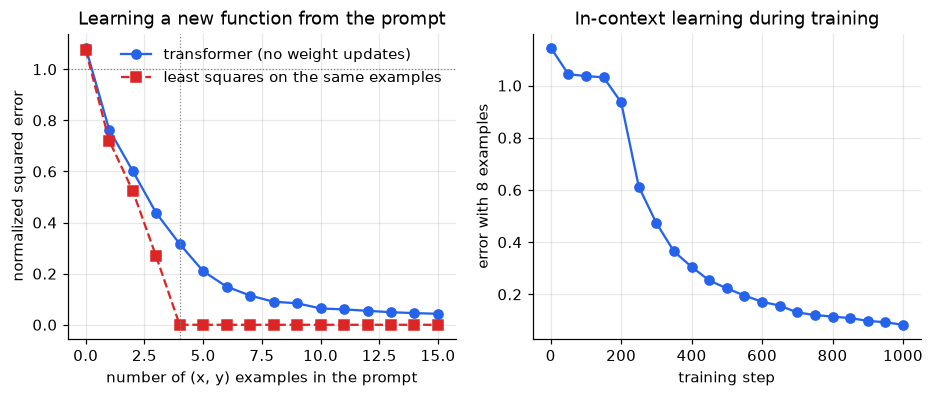

In [8]:
torch.manual_seed(0)
icl = InContextRegressor()
opt = torch.optim.AdamW(icl.parameters(), lr=1e-3, weight_decay=0.0)
gen, test_x, test_y = torch.Generator().manual_seed(0), *sample_tasks(2000, torch.Generator().manual_seed(1))


@torch.no_grad()
def icl_errors(model):
    return ((model(test_x, test_y) - test_y) ** 2).mean(0).numpy() / D_IN  # error at each number of examples


curve, t0 = {"step": [], "err8": []}, time.time()
for step in range(1001):
    for g in opt.param_groups:
        g["lr"] = 1e-3 * min(1.0, (step + 1) / 100)  # short warmup, then constant
    if step % 50 == 0:
        curve["step"].append(step)
        curve["err8"].append(icl_errors(icl)[8])
    x, y = sample_tasks(64, gen)
    loss = F.mse_loss(icl(x, y), y)
    opt.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(icl.parameters(), 1.0)
    opt.step()
print(f"trained in {time.time() - t0:.0f}s, {mlexp.count_params(icl):,} parameters")

print("error with 8 examples during training: " + ", ".join(f"step {s} {e:.2f}" for s, e in list(zip(curve["step"], curve["err8"]))[::4]))
model_err, ls_err = icl_errors(icl), least_squares_errors(test_x, test_y)
for k in [0, 1, 2, 3, 4, 8, 15]:
    print(f"{k:2d} examples in the prompt: transformer {model_err[k]:.3f}   least squares {ls_err[k]:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))
ax1.plot(model_err, "o-", label="transformer (no weight updates)")
ax1.plot(ls_err, "s--", label="least squares on the same examples")
ax1.axhline(1, color="gray", lw=0.8, ls=":")
ax1.axvline(D_IN, color="gray", lw=0.8, ls=":")
ax1.set(xlabel="number of (x, y) examples in the prompt", ylabel="normalized squared error",
        title="Learning a new function from the prompt")
ax1.legend(frameon=False)
ax2.plot(curve["step"], curve["err8"], "o-")
ax2.set(xlabel="training step", ylabel="error with 8 examples", title="In-context learning during training");

#### Why it worked: a post-mortem

**The model learns from its prompt.** No weight changes at test time, and every test function is new, yet the error falls as examples are added: 1.09 with no examples, which is no better than always guessing 0, then 0.76 with one example, 0.32 with four, 0.09 with eight and 0.04 with fifteen. **[established]** that small Transformers learn in-context linear regression (Garg et al., 2022); our numbers are one run.

**It is close to, not equal to, the optimal algorithm.** With fewer examples than unknowns it tracks least squares closely (0.76 against 0.72 with one example, 0.60 against 0.53 with two), so it has learned roughly the right procedure. But least squares hits zero error as soon as it has 4 examples, the number of unknown weights, while our model is still at 0.32 there and only 0.04 after 15. It has learned an approximate version of the algorithm, executed imprecisely by 84,000 parameters and 1,000 training steps. Garg et al. needed far larger models and longer training to match least squares almost exactly. **[established]**

**It appeared fairly suddenly during training.** The right panel tracks the error with 8 examples: it barely moves for the first 200 steps (1.15 to 0.94), then falls to 0.31 by step 400 and keeps improving slowly to 0.08. Olsson et al. (2022) saw a similar abrupt phase change when in-context learning forms in language models. **[likely]** that ours is the same phenomenon; we did not inspect the circuits.

**Why training produced it.** Because `\(w\)` is fresh in every sequence, nothing about any single function can be stored in the weights. The only thing worth storing is a *procedure* that turns earlier pairs into a prediction. Language data has the same property in a weaker form: names, formats and topics introduced earlier in a document recur later, and Olsson et al. (2022) traced the first form of this ability to "induction heads", attention circuits that find an earlier occurrence of the current token and copy what followed it. **[likely]** How much of GPT-3's few-shot ability is genuine learning, and how much is recognizing a task already seen in training, is still debated. **[speculative]**

### Step 4 (minor): emergence, or a choice of metric?

Wei et al. (2022) listed dozens of tasks, such as multi-digit arithmetic and some BIG-Bench tasks, where performance stayed near chance for small models and then jumped above it between one model size and the next. They called these **emergent abilities**: abilities you cannot predict by extrapolating smaller models. That would undercut the planning story of steps 1 and 2. **[established]** that such curves were observed.

Schaeffer et al. (2023) argued that much of this sharpness comes from the metric. Most emergent tasks were scored by **exact match**: the answer counts only if every token is right. If a model gets each token right with probability `\(p\)`, and the errors were independent, it would get a k-token answer right with probability `\(p^k\)`. As `\(p\)` creeps up smoothly, `\(p^k\)` stays near zero and then rises steeply. Score the same models with a continuous metric, such as per-token accuracy or loss, and the jump disappears.

We can check this on the step 1 ladder. For each model we measure the per-character accuracy `\(p\)` (is the most likely next character the right one?) and the exact-match rate for the next k characters, which under greedy decoding means all k predictions right in a row. Our models are small, so `\(p\)` stays below one half, and we look at short answers of 1 to 4 characters.

N =   3,088  loss 2.450  per-char accuracy p = 0.298  exact match 4 chars 0.0138 (p^4 = 0.0079)  p^10 = 5.5e-06
N =   6,160  loss 2.353  per-char accuracy p = 0.316  exact match 4 chars 0.0143 (p^4 = 0.0099)  p^10 = 9.8e-06


N =  13,944  loss 2.267  per-char accuracy p = 0.344  exact match 4 chars 0.0180 (p^4 = 0.0140)  p^10 = 2.3e-05


N =  24,672  loss 2.189  per-char accuracy p = 0.359  exact match 4 chars 0.0190 (p^4 = 0.0166)  p^10 = 3.5e-05


N =  57,640  loss 2.062  per-char accuracy p = 0.395  exact match 4 chars 0.0221 (p^4 = 0.0244)  p^10 = 9.3e-05


N =  83,280  loss 2.036  per-char accuracy p = 0.406  exact match 4 chars 0.0274 (p^4 = 0.0273)  p^10 = 1.2e-04


N = 147,520  loss 1.971  per-char accuracy p = 0.426  exact match 4 chars 0.0298 (p^4 = 0.0329)  p^10 = 2.0e-04


whole notebook so far: 312s


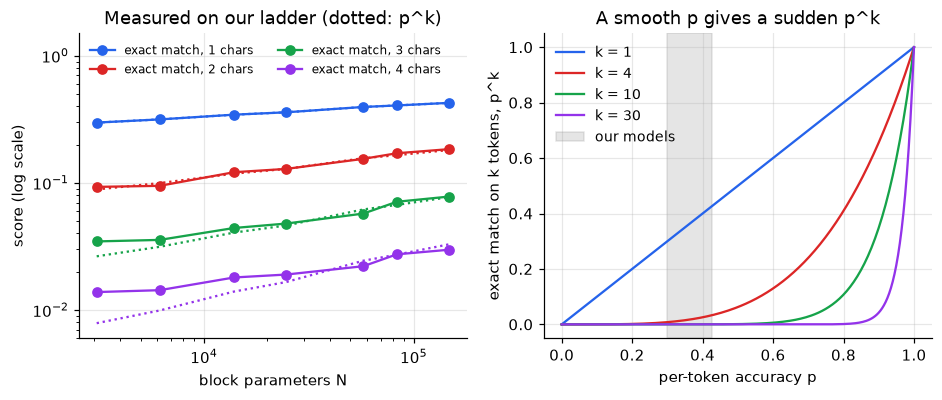

In [9]:
@torch.no_grad()
def char_hits(model):
    """For every validation position: is the model's most likely next character the right one?"""
    model.eval()
    hits = torch.cat([model(VAL_X[i:i + 128])[0].argmax(-1) == VAL_Y[i:i + 128] for i in range(0, len(VAL_X), 128)])
    model.train()
    return hits[:, 16:]  # skip the first 16 positions, which have little context


def exact_match(hits, k):
    return hits.unfold(1, k, 1).all(-1).float().mean().item()  # all k characters right in a row


KS = [1, 2, 3, 4]
scores = []
for r in ladder:
    hits = char_hits(r["model"])
    scores.append([exact_match(hits, k) for k in KS])
    print(f"N = {r['N']:7,d}  loss {r['loss']:.3f}  per-char accuracy p = {scores[-1][0]:.3f}  "
          f"exact match 4 chars {scores[-1][3]:.4f} (p^4 = {scores[-1][0] ** 4:.4f})  p^10 = {scores[-1][0] ** 10:.1e}")
scores = np.array(scores)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))
for j, k in enumerate(KS):
    line, = ax1.loglog(Ns, scores[:, j], "o-", label=f"exact match, {k} chars")
    ax1.loglog(Ns, scores[:, 0] ** k, ":", color=line.get_color())
ax1.set(xlabel="block parameters N", ylabel="score (log scale)", title="Measured on our ladder (dotted: p^k)", ylim=(0.006, 1.5))
ax1.legend(frameon=False, fontsize=8, ncol=2, loc="upper left")
p = np.linspace(0, 1, 200)
for k in [1, 4, 10, 30]:
    ax2.plot(p, p ** k, label=f"k = {k}")
ax2.axvspan(scores[:, 0].min(), scores[:, 0].max(), color="gray", alpha=0.2, label="our models")
ax2.set(xlabel="per-token accuracy p", ylabel="exact match on k tokens, p^k", title="A smooth p gives a sudden p^k")
ax2.legend(frameon=False, fontsize=9)
print(f"whole notebook so far: {time.time() - notebook_start:.0f}s")

#### Why it worked: a post-mortem

**Measured on a log axis, everything is smooth.** Across the ladder the per-character accuracy rises steadily from 0.298 to 0.426, and the exact-match rates for 2, 3 and 4 characters rise along parallel straight-ish lines on log-log axes, each one steeper than the last. Nothing switches on. On a linear axis, the 4-character score (0.014 to 0.030) would look like a flat line at zero, and a 10-character score, about `\(p^{10}\)` = 6&times;10<sup>-6</sup> to 2&times;10<sup>-4</sup>, would be indistinguishable from zero for every model we trained.

**The arithmetic does the rest.** The right panel shows `\(p^k\)` against `\(p\)`. Our models sit in the shaded band, where every long exact-match score is near zero. A family of larger models whose per-token accuracy kept climbing smoothly through 0.7, 0.8 and 0.9 would see its 30-token exact match go from about 0.00002 to 0.001 to 0.04: near zero for a long time, then a steep rise. Plotted against log model size with a linear y-axis, that is exactly the shape Wei et al. (2022) called emergent. **[established]** for the arithmetic; our ladder is a small-scale illustration of the argument in Schaeffer et al. (2023).

**`\(p^k\)` is only an approximation.** For the smallest model the measured 4-character exact match (0.014) is almost twice `\(p^4\)` (0.008), because errors are not independent: easy stretches of text, such as the rest of a common word, are easy for every character at once. For the largest model the two agree closely. Correlated errors soften the jump but do not remove it. **[likely]**

**Not every jump is a mirage.** Schaeffer et al. showed that many reported emergent abilities become smooth under continuous metrics, but not that all do. Some capabilities may need several sub-skills at once, which produces a genuine threshold, and the metric that matters to a user (did the code run, is the answer right) is often the thresholded one. The practical lesson is to forecast with metrics that track the loss, and to treat exact-match curves with care. **[likely]** Whether some abilities are truly discontinuous in scale is unsettled. **[speculative]**

## Recap

<div class="mlx-box mlx-box--objectives"><p class="mlx-box__label">Recap</p><p>You should now be able to:</p><ol><li>Fit a scaling law \(L(N) = E + A/N^{\alpha}\) to a ladder of models and read it on log-log axes.</li><li>Estimate a training run's compute as \(C \approx 6ND\) and run an IsoFLOP sweep to find the best model size for a budget.</li><li>Build a Transformer that learns linear functions from its prompt and compare it with least squares.</li><li>Explain how an exact-match metric can make a smooth improvement look like a sudden ability.</li></ol></div>

<div class="mlx-box mlx-box--check"><p class="mlx-box__label">Check your understanding</p><details><summary>A loss curve looks straight on log-log axes only after you subtract a constant. What is that constant, and why can loss not go to zero?</summary><p>It is the irreducible loss E, the entropy of the text itself. Even a perfect model cannot predict genuinely random choices in the data, so its loss stays at E. Only the part above E, the reducible loss, follows the power law.</p></details><details><summary>You have 10 times more compute. Under Chinchilla's rule, how much bigger should the model be, and how many more tokens should it see?</summary><p>Both grow as the square root of compute: about 3.2 times more parameters and 3.2 times more tokens, since 3.2 &times; 3.2 &asymp; 10 and C &asymp; 6ND.</p></details><details><summary>Why do LLaMA-style models train far past 20 tokens per parameter, if that wastes training compute?</summary><p>Chinchilla minimizes training compute only. A smaller model trained longer reaches a slightly worse loss for the same training cost, but it is much cheaper to run, and inference over millions of queries can cost more than training.</p></details><details><summary>A model's per-token accuracy rises from 0.80 to 0.90 between two sizes. What happens to its exact-match score on 20-token answers?</summary><p>Under independence it rises from 0.80<sup>20</sup> &asymp; 0.012 to 0.90<sup>20</sup> &asymp; 0.12, a tenfold jump that looks sudden, although the per-token change was modest.</p></details></div>

## Further reading

- Hestness et al., 2017, [Deep Learning Scaling is Predictable, Empirically](https://arxiv.org/abs/1712.00409).
- Kaplan et al., 2020, [Scaling Laws for Neural Language Models](https://arxiv.org/abs/2001.08361).
- Brown et al., 2020, [Language Models are Few-Shot Learners](https://arxiv.org/abs/2005.14165): GPT-3 and in-context learning.
- Hoffmann et al., 2022, [Training Compute-Optimal Large Language Models](https://arxiv.org/abs/2203.15556): Chinchilla.
- Garg et al., 2022, [What Can Transformers Learn In-Context? A Case Study of Simple Function Classes](https://arxiv.org/abs/2208.01066).
- Olsson et al., 2022, [In-context Learning and Induction Heads](https://arxiv.org/abs/2209.11895).
- Wei et al., 2022, [Emergent Abilities of Large Language Models](https://arxiv.org/abs/2206.07682).
- Schaeffer, Miranda and Koyejo, 2023, [Are Emergent Abilities of Large Language Models a Mirage?](https://arxiv.org/abs/2304.15004)